<div dir="rtl">

# گزارش تحلیل عملکرد مدل‌های طبقه‌بندی اخبار روی دیتاست Reuters

## مقدمه

هدف این آزمایش، بررسی اثر تغییر تنظیمات مختلف مدل‌های شبکه عصبی (تعداد کلمات، تعداد لایه‌ها، تعداد نرون‌ها، تابع خطا و تابع فعال‌سازی) بر دقت و خطای نهایی مدل در مسأله‌ی طبقه‌بندی چندکلاسه‌ی اخبار (با ۴۶ کلاس) در دیتاست Reuters بوده است. مدل‌ها با استفاده از داده‌های برداری‌شده‌ی متنی آموزش داده شده و عملکرد آن‌ها روی داده‌های تست ارزیابی شده‌اند.

</div>


In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers, Input
import matplotlib.pyplot as plt

# لود کردن داده‌ها
def load_data(num_words=10000):
    (train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=num_words)

    def vectorize_sequences(sequences, dimension=num_words):
        results = np.zeros((len(sequences), dimension))
        for i, sequence in enumerate(sequences):
            results[i, sequence] = 1.0
        return results

    x_train = vectorize_sequences(train_data)
    x_test = vectorize_sequences(test_data)
    y_train = to_categorical(train_labels)
    y_test = to_categorical(test_labels)

    return x_train, y_train, x_test, y_test

# ساخت مدل
def build_model(hidden_layers=2, units=64, activation='relu', loss='categorical_crossentropy', input_dim=10000):
    model = models.Sequential()
    model.add(Input(shape=(input_dim,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(46, activation='softmax'))
    model.compile(optimizer='rmsprop', loss=loss, metrics=['accuracy'])
    return model

# تعریف لیست نتایج
results = []


<div dir="rtl">

## ساختار مدل پایه

مدل پایه از دو لایه‌ی مخفی با ۶۴ نرون و تابع فعال‌سازی ReLU تشکیل شده و از تابع خطای categorical_crossentropy برای آموزش استفاده می‌کند. این مدل با ۱۰٬۰۰۰ کلمه‌ی پرتکرار آموزش داده شده و دقتی حدود ۸۰٪ و مقداری از خطا حدود ۰.۹ را به‌دست آورده است.

</div>



🔬 Running experiment: Baseline


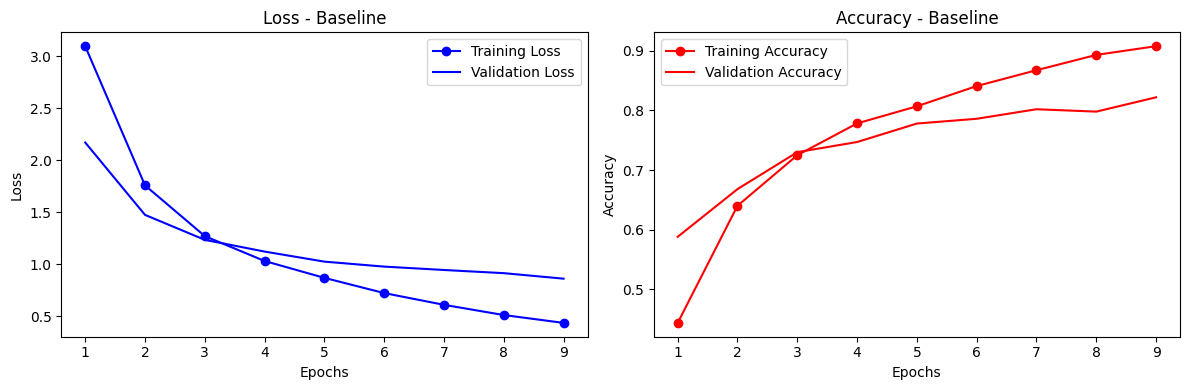


🔬 Running experiment: 5000 words


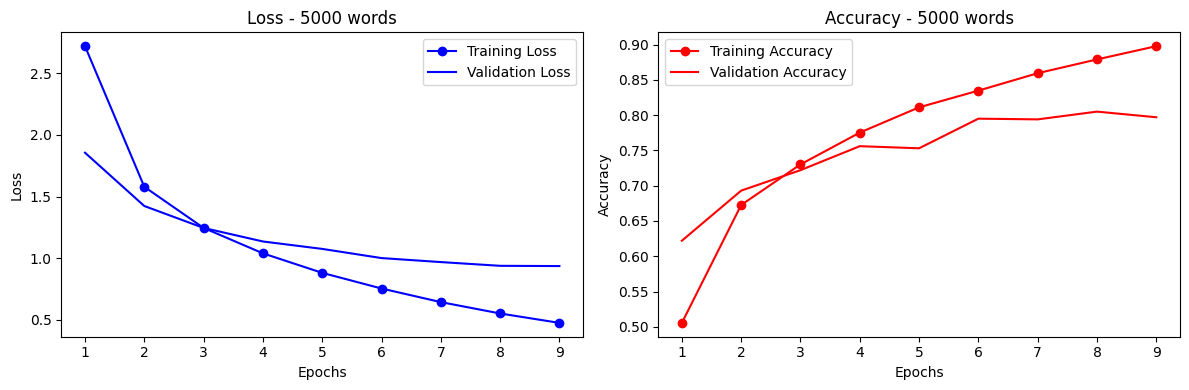


🔬 Running experiment: 20000 words


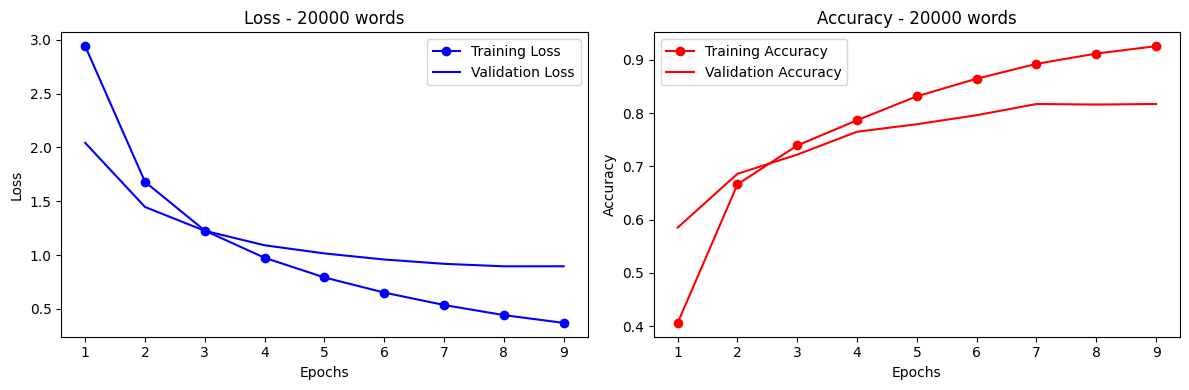

In [19]:
# آزمایش: تغییر تعداد کلمات

experiments_words = [
    {"name": "Baseline", "num_words": 10000, "layers": 2, "units": 64, "activation": 'relu', "loss": 'categorical_crossentropy'},
    {"name": "5000 words", "num_words": 5000, "layers": 2, "units": 64, "activation": 'relu', "loss": 'categorical_crossentropy'},
    {"name": "20000 words", "num_words": 20000, "layers": 2, "units": 64, "activation": 'relu', "loss": 'categorical_crossentropy'},
]

for exp in experiments_words:
    print(f"\n🔬 Running experiment: {exp['name']}")
    x_train, y_train, x_test, y_test = load_data(exp["num_words"])
    x_val = x_train[:1000]
    partial_x_train = x_train[1000:]
    y_val = y_train[:1000]
    partial_y_train = y_train[1000:]

    model = build_model(hidden_layers=exp["layers"],
                        units=exp["units"],
                        activation=exp["activation"],
                        loss=exp["loss"],
                        input_dim=exp["num_words"])

    history = model.fit(partial_x_train, partial_y_train,
                        epochs=9, batch_size=512,
                        validation_data=(x_val, y_val),
                        verbose=0)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append((exp["name"], test_acc, test_loss))

    epochs_range = range(1, 10)
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss_vals = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss_vals, 'bo-', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'b-', label='Validation Loss')
    plt.title(f"Loss - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, 'ro-', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f"Accuracy - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


<div dir="rtl">

## تغییر تعداد کلمات (واژگان) ورودی

- **۵٬۰۰۰ کلمه:** کاهش تعداد کلمات باعث افت کیفیت نمایش داده‌ها شده و مدل اطلاعات کمتری برای یادگیری در اختیار دارد. نتیجه، افت نسبی دقت و افزایش خطا بود.
- **۲۰٬۰۰۰ کلمه:** افزایش تعداد واژگان به مدل اجازه می‌دهد ویژگی‌های بیشتری از داده‌ها استخراج کند. این منجر به افزایش اندک دقت و کاهش خطا شد. البته در صورت ادامه، ممکن است بیش‌برازش (Overfitting) رخ دهد.

</div>



🔬 Running experiment: 1 layer


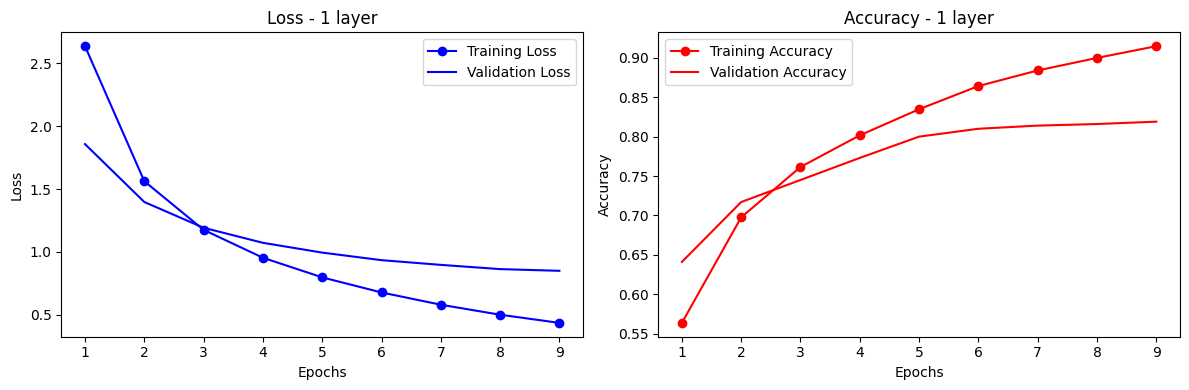


🔬 Running experiment: 3 layers


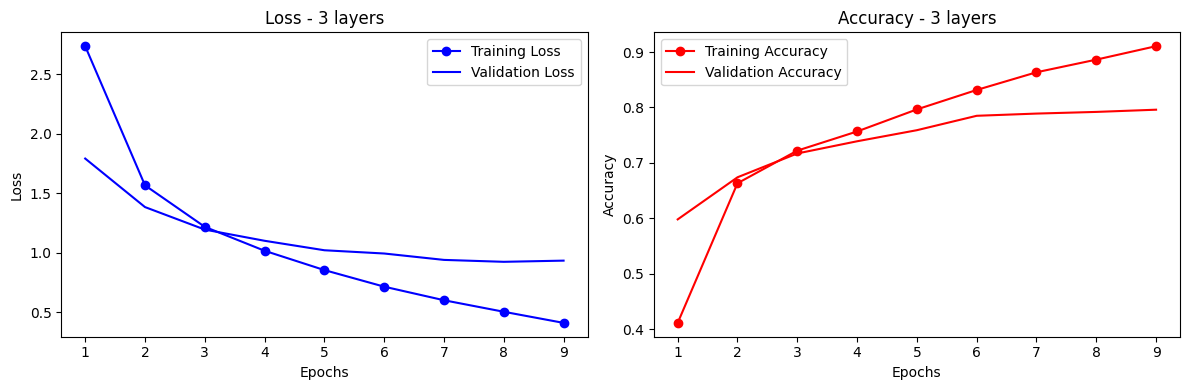

In [20]:
# آزمایش: تغییر تعداد لایه‌ها

experiments_layers = [
    {"name": "1 layer", "num_words": 10000, "layers": 1, "units": 64, "activation": 'relu', "loss": 'categorical_crossentropy'},
    {"name": "3 layers", "num_words": 10000, "layers": 3, "units": 64, "activation": 'relu', "loss": 'categorical_crossentropy'},
]

for exp in experiments_layers:
    print(f"\n🔬 Running experiment: {exp['name']}")
    x_train, y_train, x_test, y_test = load_data(exp["num_words"])
    x_val = x_train[:1000]
    partial_x_train = x_train[1000:]
    y_val = y_train[:1000]
    partial_y_train = y_train[1000:]

    model = build_model(hidden_layers=exp["layers"],
                        units=exp["units"],
                        activation=exp["activation"],
                        loss=exp["loss"],
                        input_dim=exp["num_words"])

    history = model.fit(partial_x_train, partial_y_train,
                        epochs=9, batch_size=512,
                        validation_data=(x_val, y_val),
                        verbose=0)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append((exp["name"], test_acc, test_loss))

    epochs_range = range(1, 10)
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss_vals = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss_vals, 'bo-', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'b-', label='Validation Loss')
    plt.title(f"Loss - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, 'ro-', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f"Accuracy - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


<div dir="rtl">

### تغییر تعداد لایه‌های پنهان

- **۱ لایه:** کاهش لایه‌ها باعث کاهش ظرفیت مدل در یادگیری روابط پیچیده شده و دقت نهایی افت کرد.
- **۳ لایه:** افزایش لایه‌ها در مواردی دقت مدل را کمی افزایش داد، اما هم‌زمان افزایش فاصله بین loss آموزش و اعتبارسنجی نشان‌دهنده‌ی احتمال بیش‌برازش بود.

</div>



🔬 Running experiment: 32 units


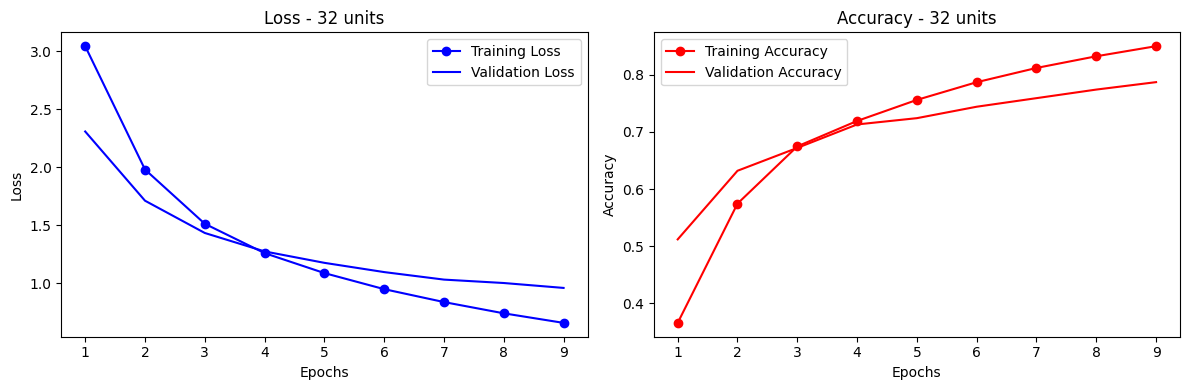


🔬 Running experiment: 128 units


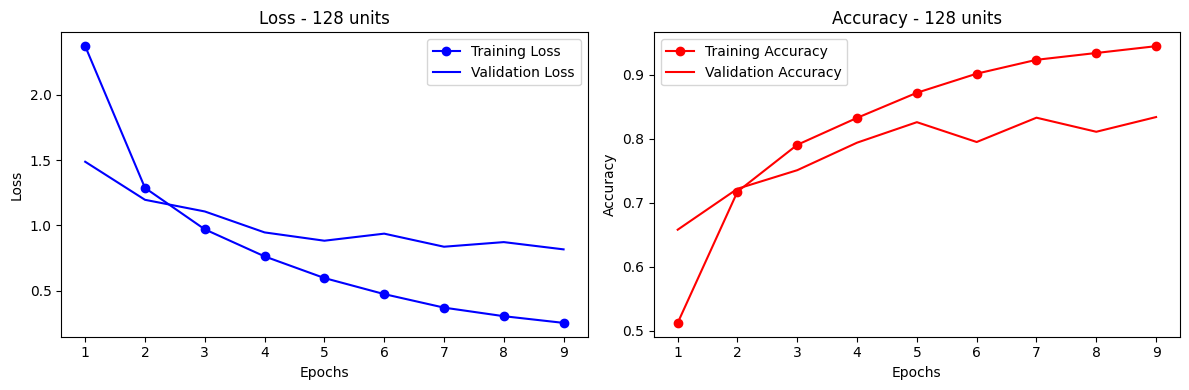

In [21]:
# آزمایش: تغییر تعداد یونیت‌ها

experiments_units = [
    {"name": "32 units", "num_words": 10000, "layers": 2, "units": 32, "activation": 'relu', "loss": 'categorical_crossentropy'},
    {"name": "128 units", "num_words": 10000, "layers": 2, "units": 128, "activation": 'relu', "loss": 'categorical_crossentropy'},
]

for exp in experiments_units:
    print(f"\n🔬 Running experiment: {exp['name']}")

    x_train, y_train, x_test, y_test = load_data(exp["num_words"])
    x_val = x_train[:1000]
    partial_x_train = x_train[1000:]
    y_val = y_train[:1000]
    partial_y_train = y_train[1000:]

    model = build_model(hidden_layers=exp["layers"],
                        units=exp["units"],
                        activation=exp["activation"],
                        loss=exp["loss"],
                        input_dim=exp["num_words"])

    history = model.fit(partial_x_train, partial_y_train,
                        epochs=9, batch_size=512,
                        validation_data=(x_val, y_val),
                        verbose=0)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append((exp["name"], test_acc, test_loss))

    epochs_range = range(1, 10)
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss_vals = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss_vals, 'bo-', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'b-', label='Validation Loss')
    plt.title(f"Loss - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, 'ro-', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f"Accuracy - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


<div dir="rtl">

### تغییر تعداد نرون‌ها در هر لایه

- **۳۲ نرون:** کاهش تعداد نرون‌ها توان مدل را برای یادگیری محدود کرده و موجب کاهش دقت شد.
- **۱۲۸ نرون:** افزایش نرون‌ها کمک کرد ویژگی‌های بیشتری آموخته شود و دقت کمی بهبود یافت، اما همراه با افزایش احتمال overfitting بود.

</div>



🔬 Running experiment: Loss = MSE


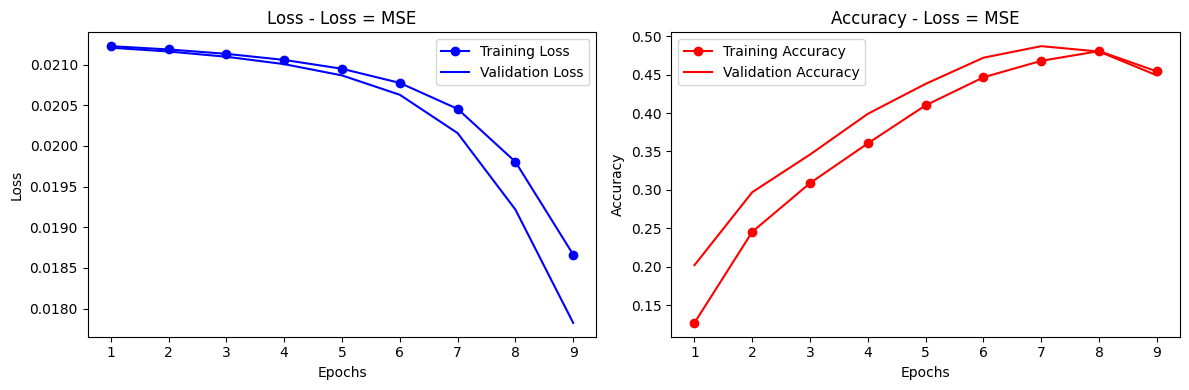

In [22]:
# آزمایش: تغییر تابع خطا (Loss Function)

experiments_loss = [
    {"name": "Loss = MSE", "num_words": 10000, "layers": 2, "units": 64, "activation": 'relu', "loss": 'mse'},
]

for exp in experiments_loss:
    print(f"\n🔬 Running experiment: {exp['name']}")
    x_train, y_train, x_test, y_test = load_data(exp["num_words"])
    x_val = x_train[:1000]
    partial_x_train = x_train[1000:]
    y_val = y_train[:1000]
    partial_y_train = y_train[1000:]

    model = build_model(hidden_layers=exp["layers"],
                        units=exp["units"],
                        activation=exp["activation"],
                        loss=exp["loss"],
                        input_dim=exp["num_words"])

    history = model.fit(partial_x_train, partial_y_train,
                        epochs=9, batch_size=512,
                        validation_data=(x_val, y_val),
                        verbose=0)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append((exp["name"], test_acc, test_loss))

    epochs_range = range(1, 10)
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss_vals = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss_vals, 'bo-', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'b-', label='Validation Loss')
    plt.title(f"Loss - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, 'ro-', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f"Accuracy - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


<div dir="rtl">

### تغییر تابع خطا

- **MSE (میانگین مربعات خطا):** این تابع به‌طور طبیعی برای مسائل رگرسیون طراحی شده است. استفاده از آن در مسأله‌ی طبقه‌بندی چندکلاسه، باعث افت شدید دقت مدل و ناکارآمدی در یادگیری شد.

</div>



🔬 Running experiment: Activation = tanh


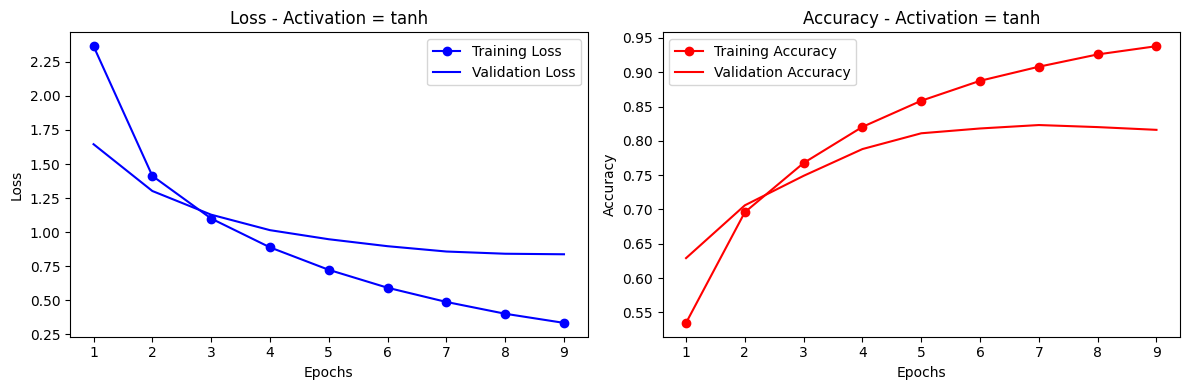

In [23]:
# آزمایش: تغییر تابع فعال‌سازی (Activation Function)

experiments_activation = [
    {"name": "Activation = tanh", "num_words": 10000, "layers": 2, "units": 64, "activation": 'tanh', "loss": 'categorical_crossentropy'},
]

for exp in experiments_activation:
    print(f"\n🔬 Running experiment: {exp['name']}")
    x_train, y_train, x_test, y_test = load_data(exp["num_words"])
    x_val = x_train[:1000]
    partial_x_train = x_train[1000:]
    y_val = y_train[:1000]
    partial_y_train = y_train[1000:]

    model = build_model(hidden_layers=exp["layers"],
                        units=exp["units"],
                        activation=exp["activation"],
                        loss=exp["loss"],
                        input_dim=exp["num_words"])

    history = model.fit(partial_x_train, partial_y_train,
                        epochs=9, batch_size=512,
                        validation_data=(x_val, y_val),
                        verbose=0)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append((exp["name"], test_acc, test_loss))

    epochs_range = range(1, 10)
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss_vals = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss_vals, 'bo-', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'b-', label='Validation Loss')
    plt.title(f"Loss - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, 'ro-', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f"Accuracy - {exp['name']}")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


<div dir="rtl">

### تغییر تابع فعال‌سازی

- **Tanh:** جایگزینی ReLU با Tanh منجر به کاهش دقت و افزایش loss شد. Tanh در لایه‌های عمیق‌تر باعث اشباع شدن گرادیان و کندی یادگیری می‌شود.

</div>



Final Results:
Baseline             | Accuracy: 0.7876 | Loss: 0.9695
5000 words           | Accuracy: 0.7698 | Loss: 0.9850
20000 words          | Accuracy: 0.7836 | Loss: 0.9741
1 layer              | Accuracy: 0.7934 | Loss: 0.9020
3 layers             | Accuracy: 0.7734 | Loss: 1.0137
32 units             | Accuracy: 0.7636 | Loss: 1.0603
128 units            | Accuracy: 0.8054 | Loss: 0.9077
Loss = MSE           | Accuracy: 0.4581 | Loss: 0.0179
Activation = tanh    | Accuracy: 0.7934 | Loss: 0.9139


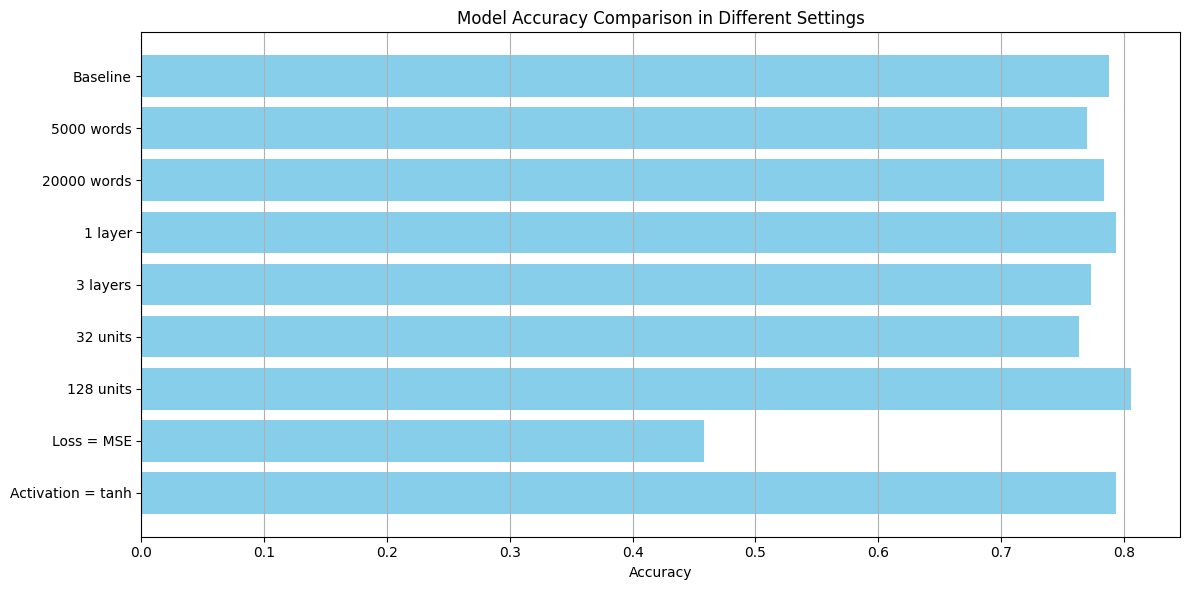

In [24]:
# نمایش نتایج نهایی
print("\nFinal Results:")
for name, acc, loss in results:
    print(f"{name:20s} | Accuracy: {acc:.4f} | Loss: {loss:.4f}")

# رسم نمودار مقایسه‌ای دقت مدل‌ها
names = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.figure(figsize=(12, 6))
plt.barh(names, accuracies, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison in Different Settings')
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


<div dir="rtl">

## نتیجه‌گیری

مدل پایه با تنظیمات متعادل (۲ لایه، ۶۴ نرون، ReLU، Crossentropy، ۱۰٬۰۰۰ کلمه) عملکرد خوبی روی داده‌های متنی دیتاست Reuters دارد. تغییرات اعمال‌شده نشان دادند که افزایش ظرفیت مدل تا حدی مفید است اما فراتر رفتن از آن منجر به بیش‌برازش می‌شود. همچنین انتخاب تابع خطا و تابع فعال‌سازی مناسب برای نوع مسئله نقش کلیدی در عملکرد مدل دارد.

</div>
